In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

d:\Switch\Cost Sensitive Risk Model\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_full = pd.read_csv("D:\\Switch\\Cost Sensitive Risk Model\\Data\\accepted_2007_to_2018Q4.csv", low_memory=False)
df = df_full.sample(n=200000, random_state=42)
del df_full

#For experimentation, I will only be loading the random 200k rows. The data has 2.3 million rows.

In [3]:
df.shape

(200000, 151)

In [4]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)

In [5]:
df['loan_status'].unique()
df['loan_status'].value_counts(normalize=True)

loan_status
Fully Paid                                             0.475110
Current                                                0.389143
Charged Off                                            0.118942
Late (31-120 days)                                     0.009925
In Grace Period                                        0.003765
Late (16-30 days)                                      0.002030
Does not meet the credit policy. Status:Fully Paid     0.000765
Does not meet the credit policy. Status:Charged Off    0.000305
Default                                                0.000015
Name: proportion, dtype: float64

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 200000 entries, 392949 to 1005720
Columns: 151 entries, id to settlement_term
dtypes: float64(113), str(38)
memory usage: 231.9 MB


In [7]:

null_pct = df.isnull().mean().sort_values(ascending=False)
null_pct.head(20)
#A lot of columns have high sparsity.

member_id                                     1.000000
orig_projected_additional_accrued_interest    0.996345
hardship_reason                               0.995270
hardship_payoff_balance_amount                0.995270
hardship_last_payment_amount                  0.995270
payment_plan_start_date                       0.995270
hardship_type                                 0.995270
hardship_status                               0.995270
hardship_start_date                           0.995270
deferral_term                                 0.995270
hardship_amount                               0.995270
hardship_dpd                                  0.995270
hardship_loan_status                          0.995270
hardship_length                               0.995270
hardship_end_date                             0.995270
settlement_status                             0.984690
debt_settlement_flag_date                     0.984690
settlement_term                               0.984690
settlement

In [8]:
#Finding columns with 90% or more null values
null_pct = df.isnull().mean()

high_null_cols = null_pct[null_pct >= 0.9].index

len(high_null_cols)

38

In [9]:
high_null_cols
#All the columns appear useless/noise at this stage so it is a better decision to drop them.

Index(['member_id', 'desc', 'annual_inc_joint', 'dti_joint',
       'verification_status_joint', 'revol_bal_joint',
       'sec_app_fico_range_low', 'sec_app_fico_range_high',
       'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
       'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
       'sec_app_open_act_il', 'sec_app_num_rev_accts',
       'sec_app_chargeoff_within_12_mths',
       'sec_app_collections_12_mths_ex_med',
       'sec_app_mths_since_last_major_derog', 'hardship_type',
       'hardship_reason', 'hardship_status', 'deferral_term',
       'hardship_amount', 'hardship_start_date', 'hardship_end_date',
       'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
       'hardship_loan_status', 'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlem

In [10]:
df = df.drop(columns=high_null_cols)

In [11]:
df.shape

(200000, 113)

In [12]:
#Leakage Pruning
#We have to figure out the columns that define what happened after the loan was approved
leakage_keywords = [
    'pymnt',
    'recover',
    'collection',
    'out_prncp',
    'last_',
    'settlement',
    'hardship',
    'chargeoff',
    'delinq_amnt'
]

leakage_cols = [
    col for col in df.columns
    if any(keyword in col for keyword in leakage_keywords)
]



In [13]:

leakage_cols

['pymnt_plan',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'inq_last_12m',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'hardship_flag',
 'debt_settlement_flag']

In [14]:
cols_to_drop = [
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'chargeoff_within_12_mths',
    'delinq_amnt',
    'hardship_flag',
    'debt_settlement_flag'
]

df = df.drop(columns=cols_to_drop)

#These columns define what happened after the loan was approved

In [15]:
df.shape

(200000, 97)

In [16]:
#Next up is cleaning our most important column-loan_status
#We removed statuses like Current, Late, In Grace Period, and Default because they represent ongoing or unresolved loans, meaning the final outcome (default vs paid) is not yet known.
valid_status = [
    "Fully Paid",
    "Charged Off",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off"
]

df = df[df['loan_status'].isin(valid_status)]


In [17]:
df['target'] = df['loan_status'].apply(
    lambda x: 1 if "Charged Off" in x else 0
)


In [18]:
df['target'].value_counts(normalize=True)

target
0    0.799625
1    0.200375
Name: proportion, dtype: float64

The data is moderatly imbalanced, usual for credit risks.

In [19]:
df.shape

(119022, 98)

In [20]:
#Feature inspection
df.dtypes.value_counts()

float64    77
str        20
int64       1
Name: count, dtype: int64

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

len(num_cols), len(cat_cols)

C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\285525040.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


(78, 20)

In [22]:
#Check for high cordinality
for col in cat_cols:
    print(col, df[col].nunique())

id 119022
term 2
grade 7
sub_grade 35
emp_title 51370
emp_length 11
home_ownership 6
verification_status 3
issue_d 138
loan_status 4
pymnt_plan 1
url 119022
purpose 14
title 7791
zip_code 877
addr_state 51
earliest_cr_line 661
initial_list_status 2
application_type 2
disbursement_method 2


In [23]:
#Dropping columns with high cardinality
drop_cols = ['id', 'url', 'emp_title', 'title', 'zip_code']

df = df.drop(columns=drop_cols)

In [24]:
df.shape

(119022, 93)

In [25]:
#Final columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

len(num_cols), len(cat_cols)


C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\4124110532.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


(78, 15)

In [26]:
df[cat_cols].isnull().mean().sort_values(ascending=False).head(10)

emp_length             0.05762
grade                  0.00000
term                   0.00000
sub_grade              0.00000
home_ownership         0.00000
verification_status    0.00000
issue_d                0.00000
loan_status            0.00000
pymnt_plan             0.00000
purpose                0.00000
dtype: float64

In [27]:
df = df.drop(columns=['loan_status'])

In [28]:
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [29]:
df.isnull().mean().sort_values(ascending=False).head(20)

mths_since_last_record            0.829779
mths_since_recent_bc_dlq          0.761380
mths_since_last_major_derog       0.736133
mths_since_recent_revol_delinq    0.664054
il_util                           0.653602
mths_since_rcnt_il                0.610291
all_util                          0.600175
open_acc_6m                       0.600141
open_act_il                       0.600141
open_rv_24m                       0.600141
max_bal_bc                        0.600141
inq_fi                            0.600141
open_il_24m                       0.600141
open_il_12m                       0.600141
inq_last_12m                      0.600141
total_bal_il                      0.600141
open_rv_12m                       0.600141
total_cu_tl                       0.600141
mths_since_last_delinq            0.502420
mths_since_recent_inq             0.131093
dtype: float64

In [30]:
#Handling missing values in numeric columns.
null_pct = df[num_cols].isnull().mean().sort_values(ascending=False)

high_missing = null_pct[null_pct > 0.6]
moderate_missing = null_pct[(null_pct > 0.05) & (null_pct <= 0.6)]
low_missing = null_pct[null_pct <= 0.05]

len(high_missing), len(moderate_missing), len(low_missing)


(18, 25, 35)

In [31]:
#High missing columns are
high_missing.index

Index(['mths_since_last_record', 'mths_since_recent_bc_dlq',
       'mths_since_last_major_derog', 'mths_since_recent_revol_delinq',
       'il_util', 'mths_since_rcnt_il', 'all_util', 'open_il_24m',
       'open_acc_6m', 'total_cu_tl', 'total_bal_il', 'open_rv_12m',
       'open_rv_24m', 'max_bal_bc', 'inq_fi', 'inq_last_12m', 'open_il_12m',
       'open_act_il'],
      dtype='str')

In [32]:
#These features are installment loan features. Simply dropping them is not a wise decision and them being null is itself a signal.
#Plan-> 
# 18 high → indicator + fill 0

# 25 moderate → indicator + median

# 35 low → median only
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target')

null_pct = df[num_cols].isnull().mean()

high_missing = null_pct[null_pct > 0.6].index
moderate_missing = null_pct[(null_pct > 0.05) & (null_pct <= 0.6)].index
low_missing = null_pct[null_pct <= 0.05].index


In [33]:
for col in high_missing:
    df[col + "_missing"] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(0)

In [34]:
for col in moderate_missing:
    df[col + "_missing"] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())


C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\1819464461.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isnull().astype(int)
C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\1819464461.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isnull().astype(int)
C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\1819464461.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti

In [35]:
for col in low_missing:
    df[col] = df[col].fillna(df[col].median())

In [36]:
df[num_cols].isnull().sum().sum()

np.int64(0)

In [37]:
df.shape

(119022, 135)

In [38]:
#Next step is handling categorical Data
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols


C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\2500778964.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Index(['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'application_type',
       'disbursement_method'],
      dtype='str')

In [39]:
df[cat_cols].isnull().sum()

term                   0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
verification_status    0
issue_d                0
pymnt_plan             0
purpose                0
addr_state             0
earliest_cr_line       0
initial_list_status    0
application_type       0
disbursement_method    0
dtype: int64

In [40]:
#Handling Dates
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

df['credit_age'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
df['issue_year'] = df['issue_d'].dt.year

df = df.drop(columns=['issue_d', 'earliest_cr_line'])


C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\687508531.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['credit_age'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
C:\Users\Garvit Chandel\AppData\Local\Temp\ipykernel_1820\687508531.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['issue_year'] = df['issue_d'].dt.year


In [41]:
df.shape


(119022, 135)

Encoding Categorical Features

In [42]:
#Ordinal Encoding Grade,Sub Grade and emp_length
grade_map = {g: i for i, g in enumerate(sorted(df['grade'].unique()))}
df['grade'] = df['grade'].map(grade_map)

In [43]:
subgrade_map = {g: i for i, g in enumerate(sorted(df['sub_grade'].unique()))}
df['sub_grade'] = df['sub_grade'].map(subgrade_map)


In [44]:
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)
df['emp_length'] = df['emp_length'].fillna(0)

In [45]:
df['emp_length'].dtype

dtype('float64')

In [46]:
df['emp_length'] = df['emp_length'].fillna(0)

In [47]:
#Binary Encoding
df['term'] = df['term'].str.extract(r'(\d+)').astype(int)
df['pymnt_plan'] = df['pymnt_plan'].map({'n':0, 'y':1})
df['initial_list_status'] = df['initial_list_status'].map({'w':0, 'f':1})


In [48]:
#One Hot encoding
nominal_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'addr_state',
    'application_type',
    'disbursement_method'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


In [49]:
df.shape

(119022, 201)

Train Test Split

In [50]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [51]:
y_train.mean(), y_test.mean()


(np.float64(0.20037388281504354), np.float64(0.2003780718336484))

Baseline Model First-> Linear Regression

In [52]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)


d:\Switch\Cost Sensitive Risk Model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
y_train_proba = log_reg.predict_proba(X_train)[:, 1]
y_test_proba = log_reg.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

roc_auc, pr_auc


(0.9998031872215972, 0.9997269159299095)

Impossible Numbers-> Data Leakage

In [55]:
import pandas as pd

corr = pd.concat([X_train, y_train], axis=1).corr()['target'].abs().sort_values(ascending=False)
corr.head(15)


target                  1.000000
total_rec_prncp         0.437563
sub_grade               0.270388
grade                   0.264871
int_rate                0.261774
term                    0.176521
total_rec_late_fee      0.154416
fico_range_low          0.130764
fico_range_high         0.130762
acc_open_past_24mths    0.099053
num_tl_op_past_12m      0.083929
dti                     0.080840
bc_open_to_buy          0.078954
tot_hi_cred_lim         0.072124
avg_cur_bal             0.071406
Name: target, dtype: float64

total_rec_prncp
total_rec_late_fee

These are post-loan repayment variables. This is our data leakage.

In [56]:
leakage_remaining = [
    'total_rec_prncp',
    'total_rec_late_fee'
]

df = df.drop(columns=leakage_remaining)


Training model Again

In [57]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [58]:
y_train.mean(), y_test.mean()


(np.float64(0.20037388281504354), np.float64(0.2003780718336484))

In [59]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)


d:\Switch\Cost Sensitive Risk Model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Yeah I would need to scale the features and test again but the results seem realistic for now so I'll proceed without it.

In [60]:
y_train_proba = log_reg.predict_proba(X_train)[:, 1]
y_test_proba = log_reg.predict_proba(X_test)[:, 1]

In [61]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

roc_auc, pr_auc


(0.6673426585364376, 0.328577814034166)

COST EVALUATION AT THRESHOLD
We use:

FN cost = 500

FP cost = 10

In [62]:
import numpy as np
from sklearn.metrics import confusion_matrix

threshold = 0.5
y_pred_05 = (y_test_proba >= threshold).astype(int)


In [63]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_05).ravel()
tn, fp, fn, tp


(np.int64(18916), np.int64(119), np.int64(4681), np.int64(89))

Massive false negative shows that the model is extremely conservative at our threshold and is not catching the defaulters.

In [64]:
#Expected Loss
cost_fn = 500
cost_fp = 10

expected_loss = fn * cost_fn + fp * cost_fp
expected_loss


np.int64(2341690)

In [65]:
#Computing loss across many thresholds
thresholds = np.linspace(0.01, 0.99, 99)
losses = []

for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    loss = fn * 500 + fp * 10
    losses.append(loss)


In [66]:
min_loss = min(losses)
optimal_threshold = thresholds[np.argmin(losses)]

optimal_threshold, min_loss

(np.float64(0.01), np.int64(190440))

Okay so it seems the model has to be very aggressive. That is because the assumed cost for FN is 500 and that for FP is 10. The cost of FN is very high with respect to FP.

In [67]:
optimal_t = optimal_threshold

y_pred_opt = (y_test_proba >= optimal_t).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

tn, fp, fn, tp


(np.int64(41), np.int64(18994), np.int64(1), np.int64(4769))

Only a single FN. Model is ultimately suggesting that it is far cheaper to reject everyone than to miss a defaulter.

In [68]:
import pandas as pd

results = pd.DataFrame({
    "threshold": thresholds,
    "loss": losses
})

results_sorted = results.sort_values("loss").head(5)

results_sorted


,threshold,loss
0,0.01,190440
1,0.02,191260
2,0.03,197150
4,0.05,199630
3,0.04,199970


It seems there is no balance as loss is increasing when we increase threshold.

ROC-Optimal Threshold
We find threshold that maximizes Youden’s J:

J=TPR−FPR
J=TPR−FP

In [69]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

youden_j = tpr - fpr

roc_opt_index = np.argmax(youden_j)
roc_opt_threshold = roc_thresholds[roc_opt_index]

roc_opt_threshold


np.float64(0.2277661545456979)

In [70]:
t = roc_opt_threshold

y_pred_roc = (y_test_proba >= t).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_roc).ravel()

tn, fp, fn, tp


(np.int64(13357), np.int64(5678), np.int64(2182), np.int64(2588))

In [71]:
loss_roc = fn * 500 + fp * 10
loss_roc

np.int64(1147780)

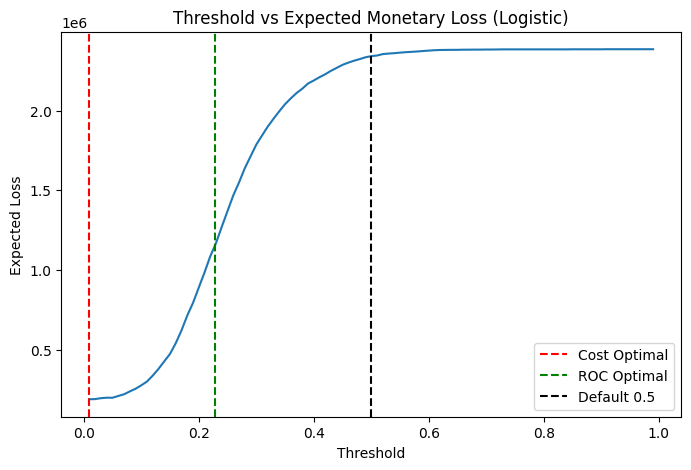

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(thresholds, losses)
plt.axvline(optimal_threshold, color='r', linestyle='--', label='Cost Optimal')
plt.axvline(roc_opt_threshold, color='g', linestyle='--', label='ROC Optimal')
plt.axvline(0.5, color='black', linestyle='--', label='Default 0.5')

plt.xlabel("Threshold")
plt.ylabel("Expected Loss")
plt.title("Threshold vs Expected Monetary Loss (Logistic)")
plt.legend()
plt.show()


XGBoost Model

In [73]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_test_proba_xgb = xgb.predict_proba(X_test)[:, 1]


In [74]:
roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_test_proba_xgb)

roc_auc_xgb, pr_auc_xgb


(0.7666183335453448, 0.4705408668335515)

In [75]:
#Optimal threshold
thresholds = np.linspace(0.01, 0.99, 99)

losses_xgb = []

for t in thresholds:
    y_pred = (y_test_proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    loss = fn * 500 + fp * 10
    losses_xgb.append(loss)

min_loss_xgb = min(losses_xgb)
optimal_threshold_xgb = thresholds[np.argmin(losses_xgb)]

optimal_threshold_xgb, min_loss_xgb


(np.float64(0.03), np.int64(189090))

In [76]:
optimal_t_xgb = optimal_threshold_xgb

y_pred_xgb_opt = (y_test_proba_xgb >= optimal_t_xgb).astype(int)

tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(y_test, y_pred_xgb_opt).ravel()

tn_xgb, fp_xgb, fn_xgb, tp_xgb


(np.int64(726), np.int64(18309), np.int64(12), np.int64(4758))

In [77]:
fn_xgb * 500 + fp_xgb * 10


np.int64(189090)

Better results. Lets try Sensitivity analysis on Cost Ratio


In [78]:
fn_costs = [100, 250, 500, 1000]
results_sensitivity = []

for fn_cost in fn_costs:
    losses_temp = []
    
    for t in thresholds:
        y_pred = (y_test_proba_xgb >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        loss = fn * fn_cost + fp * 10
        losses_temp.append(loss)
    
    min_loss = min(losses_temp)
    opt_t = thresholds[np.argmin(losses_temp)]
    
    results_sensitivity.append((fn_cost, opt_t, min_loss))

results_sensitivity


[(100, np.float64(0.11), np.int64(163370)),
 (250, np.float64(0.04), np.int64(184940)),
 (500, np.float64(0.03), np.int64(189090)),
 (1000, np.float64(0.01), np.int64(190300))]

Threshold is inversely proportional to FN cost. Optimal decision threshold is not a modeling parameter rather it’s a business parameter

Adding Approval Rate Constraint

In [79]:
min_approval = 0.40

constrained_results = []

for t in thresholds:
    y_pred = (y_test_proba_xgb >= t).astype(int)
    
    approval_rate = (y_pred == 0).mean()
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    loss = fn * 500 + fp * 10
    
    if approval_rate >= min_approval:
        constrained_results.append((t, approval_rate, loss))

# Convert to DataFrame
constrained_df = pd.DataFrame(constrained_results,
                              columns=['threshold', 'approval_rate', 'loss'])

constrained_df.sort_values('loss').head()


,threshold,approval_rate,loss
0,0.13,0.410082,431370
1,0.14,0.446041,474830
2,0.15,0.478177,518690
3,0.16,0.508465,566560
4,0.17,0.538920,616430


With 40% approval rate, we have our best threshold.

Moving on to SHAP Interpretability

In [80]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)


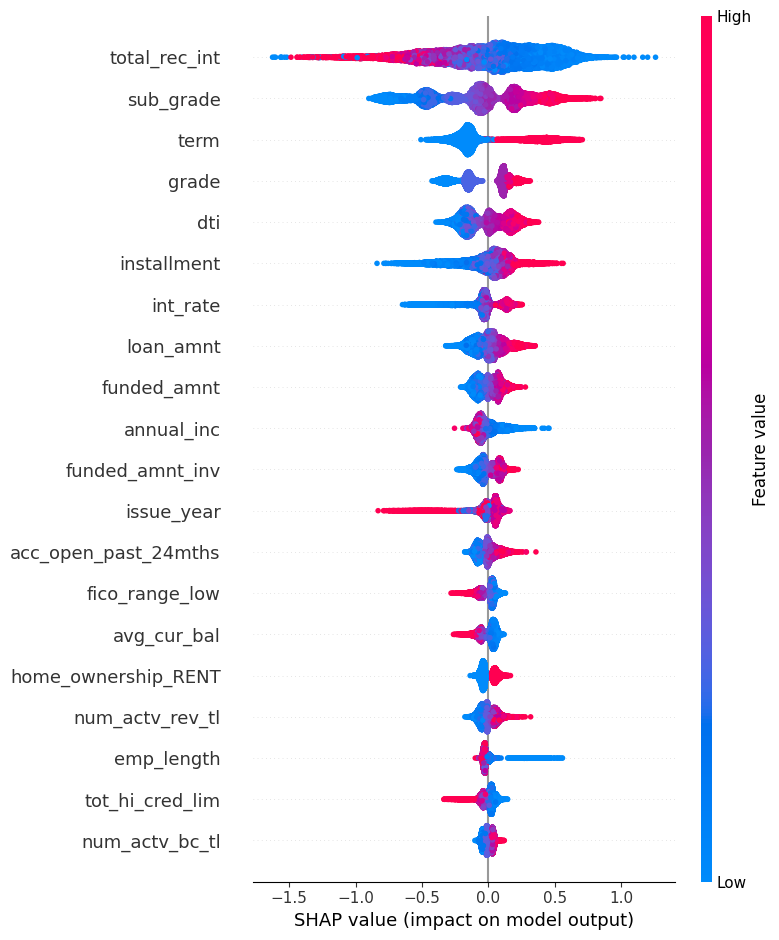

In [81]:
shap.summary_plot(shap_values, X_test)


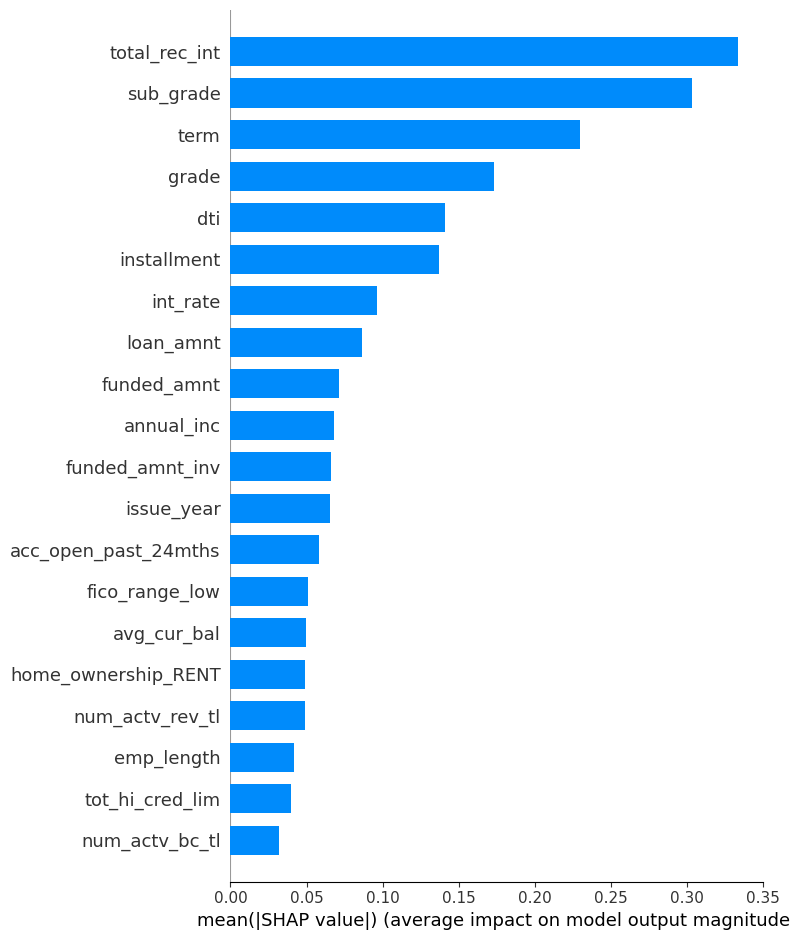

In [82]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


Okay so I just realised that I have missed another Leakage column-> total_rec_int and quite possibly funded_amnt_inv and
funded_amnt are also leakage columns

In [83]:
leakage_extra = [
    'total_rec_int',
    'funded_amnt_inv',
    'funded_amnt'
]


In [84]:
df = df.drop(columns=[col for col in leakage_extra if col in df.columns])


In [85]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [86]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_test_proba_xgb = xgb.predict_proba(X_test)[:, 1]


In [87]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_test_proba_xgb)

roc_auc_xgb, pr_auc_xgb


(0.731118192846786, 0.4174090732574634)

SHAP revealed hidden leakage via repayment variables. After removing them, model performance dropped to realistic levels.

In [88]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01, 0.99, 99)


In [89]:
losses_xgb_clean = []

for t in thresholds:
    y_pred = (y_test_proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    loss = fn * 500 + fp * 10
    losses_xgb_clean.append(loss)


In [90]:
min_loss_xgb_clean = min(losses_xgb_clean)
optimal_threshold_xgb_clean = thresholds[np.argmin(losses_xgb_clean)]

optimal_threshold_xgb_clean, min_loss_xgb_clean


(np.float64(0.02), np.int64(189310))

In [91]:
min_approval = 0.40
constrained_results = []

for t in thresholds:
    y_pred = (y_test_proba_xgb >= t).astype(int)
    
    approval_rate = (y_pred == 0).mean()
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    loss = fn * 500 + fp * 10
    
    if approval_rate >= min_approval:
        constrained_results.append((t, approval_rate, loss))

import pandas as pd
constrained_df = pd.DataFrame(constrained_results,columns=['threshold', 'approval_rate', 'loss'])

constrained_df.sort_values('loss').head()


,threshold,approval_rate,loss
0,0.14,0.405125,519250
1,0.15,0.437891,561430
2,0.16,0.469565,606930
3,0.17,0.499223,658520
4,0.18,0.530267,713860


Optimizing for Profits
Assumptions:
Loan amount = 10,000

Interest rate = 12%

Profit from good borrower ≈ 1,200

Loss given default (LGD) = 70% of principal
→ Loss ≈ 7,000

In [92]:
loan_profit = 1200
default_loss = 7000

profits = []

for t in thresholds:
    y_pred = (y_test_proba_xgb >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Approvals are predicted 0
    approvals = (y_pred == 0)
    
    # Good approvals = TN
    # Bad approvals = FN
    
    total_profit = tn * loan_profit - fn * default_loss
    
    profits.append(total_profit)

max_profit = max(profits)
optimal_profit_threshold = thresholds[np.argmax(profits)]

optimal_profit_threshold, max_profit

(np.float64(0.16), np.int64(4918400))

For Maximum Profit,we have: 

In [93]:
t = optimal_profit_threshold

y_pred_profit = (y_test_proba_xgb >= t).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_profit).ravel()

approval_rate = (y_pred_profit == 0).mean()

tn, fp, fn, tp, approval_rate

(np.int64(10142),
 np.int64(8893),
 np.int64(1036),
 np.int64(3734),
 np.float64(0.46956521739130436))

Probabibility Calibration: XGBoost probabilities are often not calibrated, Let's test with Isotonic Regression.

In [94]:
from sklearn.calibration import CalibratedClassifierCV

xgb_calibrated = CalibratedClassifierCV(
    xgb,
    method='isotonic',
    cv=5
)

xgb_calibrated.fit(X_train, y_train)

y_test_proba_cal = xgb_calibrated.predict_proba(X_test)[:, 1]

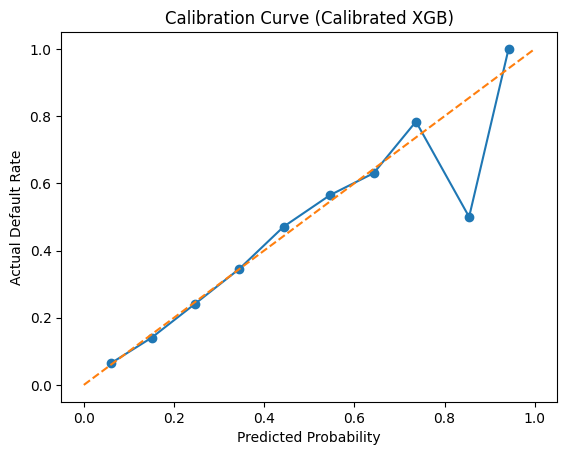

In [95]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_test_proba_cal, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve (Calibrated XGB)")
plt.show()

In [96]:
roc_auc_cal = roc_auc_score(y_test, y_test_proba_cal)
pr_auc_cal = average_precision_score(y_test, y_test_proba_cal)

roc_auc_cal, pr_auc_cal

(0.7329625664738739, 0.4192644417939355)

In [97]:
from sklearn.metrics import brier_score_loss

brier_raw = brier_score_loss(y_test, y_test_proba_xgb)
brier_cal = brier_score_loss(y_test, y_test_proba_cal)

brier_raw, brier_cal

(0.14111986756324768, 0.14077749515216284)

Brier score reveals not much of a difference. It seems raw XGB was already calibrated.

Let's perform an economic stress test. Let's assume that default probability increases by 50%.

In [98]:
stress_factor = 1.5

y_test_proba_stress = np.clip(y_test_proba_xgb * stress_factor, 0, 1)

In [99]:
profits_stress = []

for t in thresholds:
    y_pred = (y_test_proba_stress >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    total_profit = tn * 1200 - fn * 7000
    profits_stress.append(total_profit)

max_profit_stress = max(profits_stress)
optimal_threshold_stress = thresholds[np.argmax(profits_stress)]

optimal_threshold_stress, max_profit_stress

(np.float64(0.24000000000000002), np.int64(4918400))

The profit did not change. I think that is because of a flaw in implementing economic stress test. It's because I am computing profit from actual TN and FN.
One other way to do that is to increase Loss Given Default from 7000 to say 9000.

In [100]:
default_loss_stress = 9000

profits_stress = []

for t in thresholds:
    y_pred = (y_test_proba_xgb >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    total_profit = tn * 1200 - fn * default_loss_stress
    profits_stress.append(total_profit)

max_profit_stress = max(profits_stress)
optimal_threshold_stress = thresholds[np.argmax(profits_stress)]

optimal_threshold_stress, max_profit_stress

(np.float64(0.11), np.int64(3469200))

Profits decreased significantly and the model became more conservative. It seems that during recession, it is optimal to borrow risky borrowers.

In [101]:
#Checking the full portfolio under stress
t_stress = optimal_threshold_stress

y_pred_stress = (y_test_proba_xgb >= t_stress).astype(int)

tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_test, y_pred_stress).ravel()

approval_rate_stress = (y_pred_stress == 0).mean()

# Profit under stress
profit_stress = tn_s * 1200 - fn_s * 9000

# Profit per approved loan
approved_loans = tn_s + fn_s
profit_per_approved = profit_stress / approved_loans

tn_s, fp_s, fn_s, tp_s, approval_rate_stress, profit_stress, profit_per_approved

(np.int64(6611),
 np.int64(12424),
 np.int64(496),
 np.int64(4274),
 np.float64(0.2985507246376812),
 np.int64(3469200),
 np.float64(488.1384550443225))

In [106]:
t = optimal_profit_threshold  # or optimal_threshold_stress

y_pred_profit = (y_test_proba_xgb >= t).astype(int)

approval_rate = (y_pred_profit == 0).mean()
rejection_rate = (y_pred_profit == 1).mean()

approval_rate, rejection_rate, y_pred_profit.mean()

(np.float64(0.46956521739130436),
 np.float64(0.5304347826086957),
 np.float64(0.5304347826086957))



| Metric              | Normal | Stress |
| ------------------- | ------ | ------ |
| Threshold           | 0.16   | 0.11   |
| Approval Rate       | 47%    | 30%    |
| Total Profit        | 4.92M  | 3.47M  |
| Profit per Approved | ~440   | ~488   |


The entire exercise was very insightful. I used only 200k of rows instead of the 2.5 millions rows. I could have also tested with other classification algorithms, and could have implemented techniques like feature engineering for better performance.